In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression


In [2]:
train = pd.read_csv('/content/drive/MyDrive/AI_Saturday/Machine_Learning/regression_task/energy_data/train_energy_data.csv')
test = pd.read_csv('/content/drive/MyDrive/AI_Saturday/Machine_Learning/regression_task/energy_data/test_energy_data.csv')

In [3]:
train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [4]:
train.shape

(1000, 7)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Square Footage,1000.0,25462.38800,14294.554000,560.00,13169.7500,25477.000,37446.25,49997.00
Number of Occupants,1000.0,48.37200,29.061972,1.00,22.0000,47.000,73.25,99.00
Appliances Used,1000.0,25.60600,14.105166,1.00,13.0000,26.000,38.00,49.00
Average Temperature,1000.0,22.61139,7.139943,10.05,16.4750,22.815,28.85,34.99
Energy Consumption,1000.0,4166.25257,933.313064,1683.95,3509.4825,4175.730,4863.85,6530.60


In [7]:
train.nunique()

,0
Building Type,3
Square Footage,986
Number of Occupants,99
Appliances Used,49
Average Temperature,833
Day of Week,2
Energy Consumption,1000


In [8]:
train.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [9]:
train.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


# EDA

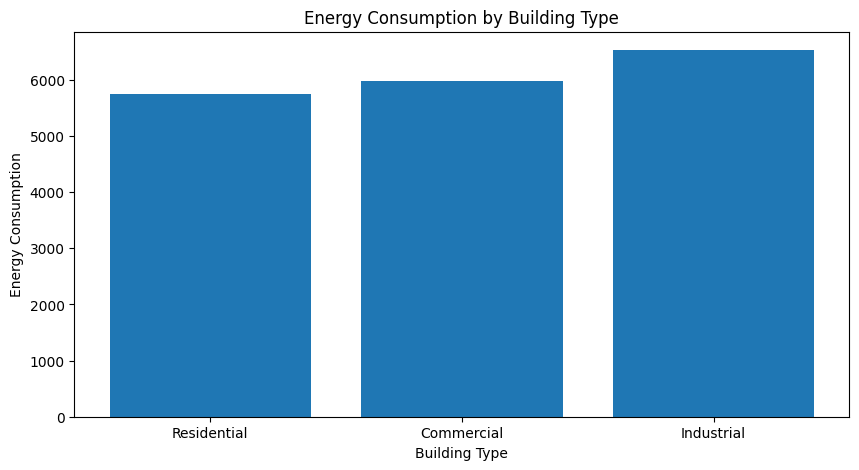

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(train['Building Type'], train['Energy Consumption'])
plt.xlabel('Building Type')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption by Building Type')
plt.show()


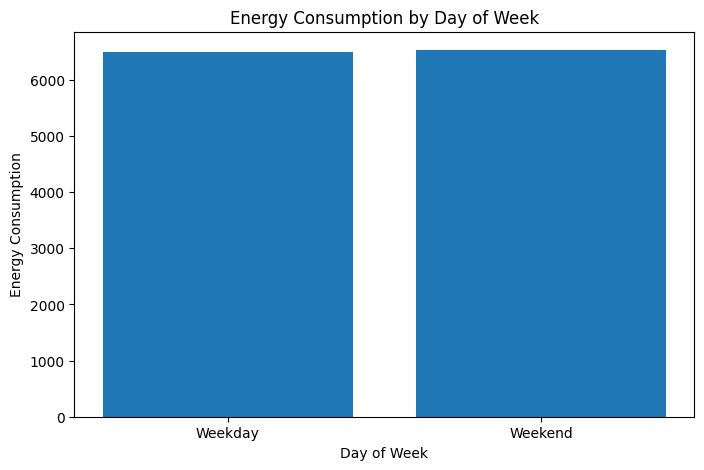

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(train['Day of Week'], train['Energy Consumption'])
plt.xlabel('Day of Week')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption by Day of Week')
plt.show()

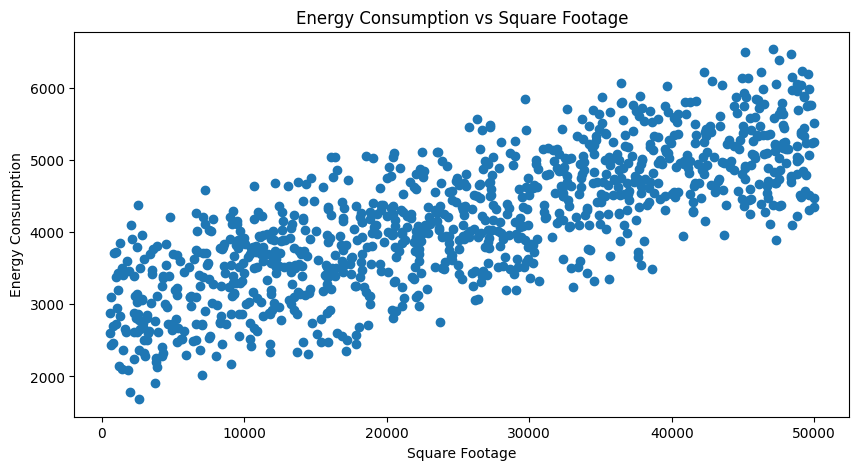

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(train['Square Footage'], train['Energy Consumption'])
plt.xlabel('Square Footage')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption vs Square Footage')
plt.show()

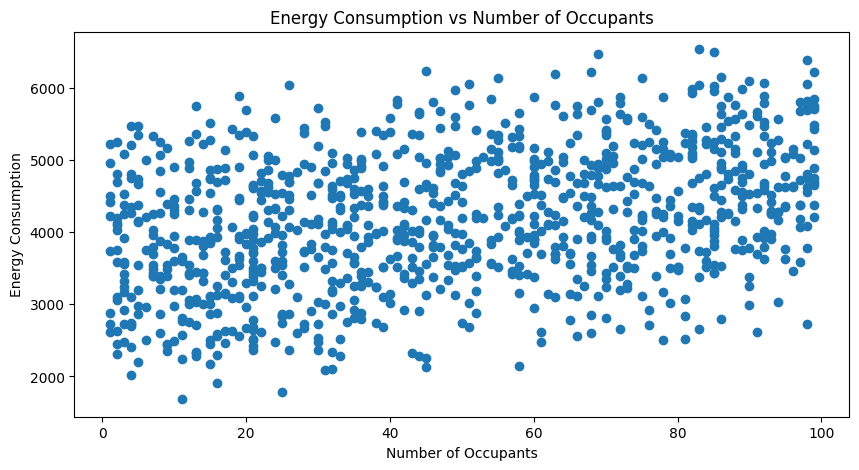

In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(train['Number of Occupants'], train['Energy Consumption'])
plt.xlabel('Number of Occupants')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption vs Number of Occupants')
plt.show()

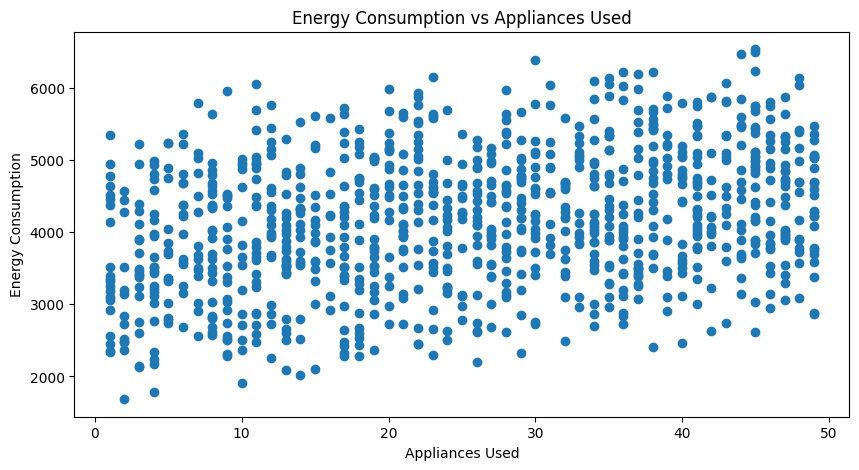

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(train['Appliances Used'], train['Energy Consumption'])
plt.xlabel('Appliances Used')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption vs Appliances Used')
plt.show()

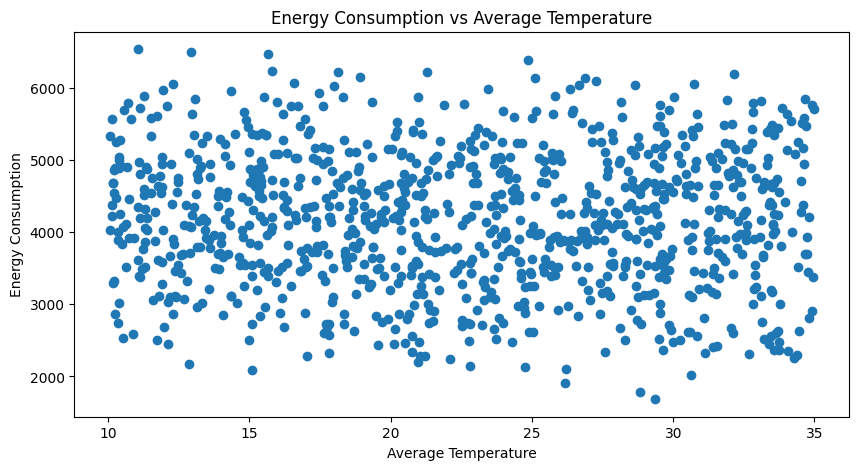

In [15]:
plt.figure(figsize=(10, 5))
plt.scatter(train['Average Temperature'], train['Energy Consumption'])
plt.xlabel('Average Temperature')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption vs Average Temperature')
plt.show()

In [16]:
# Select only numeric columns before calculating correlation
numeric_train = train.select_dtypes(include=np.number)
numeric_train.corr()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


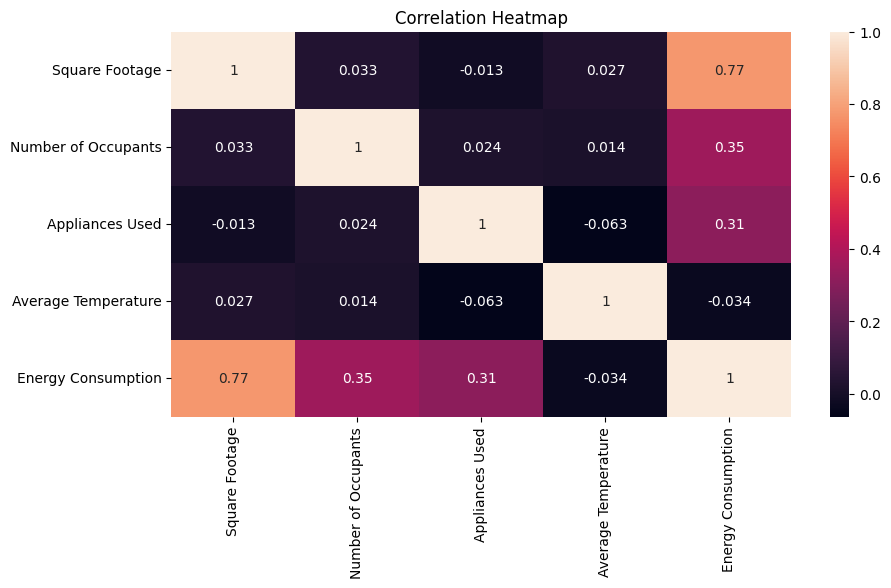

In [17]:
plt.figure(figsize=(10, 5))
sns.heatmap(numeric_train.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [18]:
# one-hot encoding of building type and day of the week
def one_hot_encode_categorical(df, categorical_cols):
  """
  Performs one-hot encoding for categorical columns in a DataFrame.

  Args:
    df: The pandas DataFrame to encode.
    categorical_cols: A list of column names to one-hot encode.

  Returns:
    A new DataFrame with the specified columns one-hot encoded.
  """
  return pd.get_dummies(df, columns=categorical_cols)




In [19]:
# Apply the function to the train set
categorical_features = ['Building Type', 'Day of Week']
train = one_hot_encode_categorical(train, categorical_features)

# Display the first few rows of the encoded train set
display(train.head())

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Day of Week_Weekday,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,False,False,True,True,False
1,44372,66,45,16.72,5744.99,True,False,False,True,False
2,19255,37,17,14.30,4101.24,False,True,False,False,True
3,13265,14,41,32.82,3009.14,False,False,True,True,False
4,13375,26,18,11.92,3279.17,True,False,False,True,False


In [20]:
# Apply the function to the test set
categorical_features = ['Building Type', 'Day of Week']
test = one_hot_encode_categorical(test, categorical_features)

# Display the first few rows of the encoded test set
display(test.head())

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Day of Week_Weekday,Day of Week_Weekend
0,24563,15,4,28.52,2865.57,False,False,True,True,False
1,27583,56,23,23.07,4283.80,True,False,False,False,True
2,45313,4,44,33.56,5067.83,True,False,False,True,False
3,41625,84,17,27.39,4624.30,False,False,True,False,True
4,36720,58,47,17.08,4820.59,False,False,True,True,False


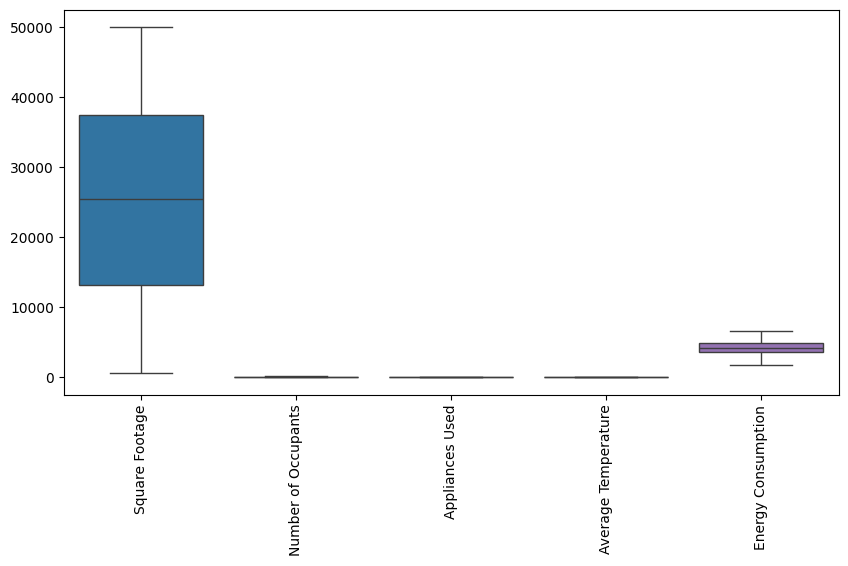

In [21]:
# box plot to check outliers in Square Footage,Number of Occupants, Appliances Used ,  Average Temperature, Energy Consumption
plt.figure(figsize=(10, 5))
sns.boxplot(data=train[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption']])
plt.xticks(rotation=90)
plt.show()

In [22]:
# fit a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,r2_score


In [23]:
target = train['Energy Consumption']
features = train.drop('Energy Consumption', axis=1)

lr = LinearRegression()
lr.fit(features, target)


LinearRegression()

# Train set

In [24]:
# mse
y_pred = lr.predict(features)
mse = mean_squared_error(target, y_pred)
print('MSE:', mse)

MSE: 0.00018631165968513875


In [25]:
# r2 score
r2 = r2_score(target, y_pred)
print('R2 score:', r2)

R2 score: 0.9999999997858984


# Test set

In [26]:
# Fit test set
test_target = test['Energy Consumption']
test_features = test.drop('Energy Consumption', axis=1)

lr_test = LinearRegression()
lr_test.fit(test_features, test_target)

LinearRegression()

In [27]:
# mse_test
y_pred_test = lr_test.predict(test_features)
mse_test = mean_squared_error(test_target, y_pred_test)
print('MSE:', mse_test)

MSE: 0.00018152838506241585


In [28]:
# r2 score test
r2_test = r2_score(test_target, y_pred_test)
print('R2 score:', r2_test)

R2 score: 0.9999999997354678
